<a href="https://colab.research.google.com/github/Chuxian-Chen/Master-Experiment/blob/main/Loan%20approval%20Dataset%20Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Descriptive statistics
import pandas as pd

# Read the dataset
df = pd.read_csv('Loan Approval Insights Data to Decision-Making.csv')

# Filtering numeric columns
numerical_cols = df.select_dtypes(include=['number']).columns

# Calculate the basic statistics (Count, Mean, Std, Min, Max).
stats = df[numerical_cols].describe().T

# Calculate the median and mode.
# Mode may have multiple values; we will take the first one. (iloc[0])
stats['median'] = df[numerical_cols].median()
stats['mode'] = df[numerical_cols].mode().iloc[0]

# Organize column names and sort them
# Order: N(Count), Minimum, Maximum, Mean, Median, Mode, Std. Deviation
numerical_stats = stats[['count', 'min', 'max', 'mean', 'median', 'mode', 'std']]
numerical_stats.columns = ['N', 'Minimum', 'Maximum', 'Mean', 'Median', 'Mode', 'Std. Deviation']

# Descriptive statistics of categorical features (count, number of unique values, mode, frequency of mode occurrence)
categorical_stats = df.describe(include=['object']).T

# Calculate skewness - a measure of the asymmetry of a distribution.
# > 0: Leaning to the right (long tail on the right side)
# < 0: Leaning to the left (long tail on the left side)
skewness = df.select_dtypes(include=['number']).skew()

# Calculate kurtosis - a measure of the steepness of a distribution or outliers.
# Peak saturation usually indicates a large number of outliers.
kurtosis = df.select_dtypes(include=['number']).kurt()

# Print results
print("--- Numerical Stats ---")
print(numerical_stats)
print("\n--- Categorical Stats ---")
print(categorical_stats)
print("\n--- Skewness ---")
print(skewness)
print("\n--- kurtosis ---")
print(kurtosis)

--- Numerical Stats ---
                                  N  Minimum     Maximum          Mean  \
person_age                  45000.0    20.00      144.00     27.764178   
person_income               45000.0  8000.00  7200766.00  80319.053222   
person_emp_exp              45000.0     0.00      125.00      5.410333   
loan_amnt                   45000.0   500.00    35000.00   9583.157556   
loan_int_rate               45000.0     5.42       20.00     11.006606   
loan_percent_income         45000.0     0.00        0.66      0.139725   
cb_person_cred_hist_length  45000.0     2.00       30.00      5.867489   
credit_score                45000.0   390.00      850.00    632.608756   
loan_status                 45000.0     0.00        1.00      0.222222   

                              Median      Mode  Std. Deviation  
person_age                     26.00     23.00        6.045108  
person_income               67048.00   8000.00    80422.498632  
person_emp_exp                  4.00    

/tmp/ipykernel_26362/2360296455.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x, y=y, data=data, palette="Set2")


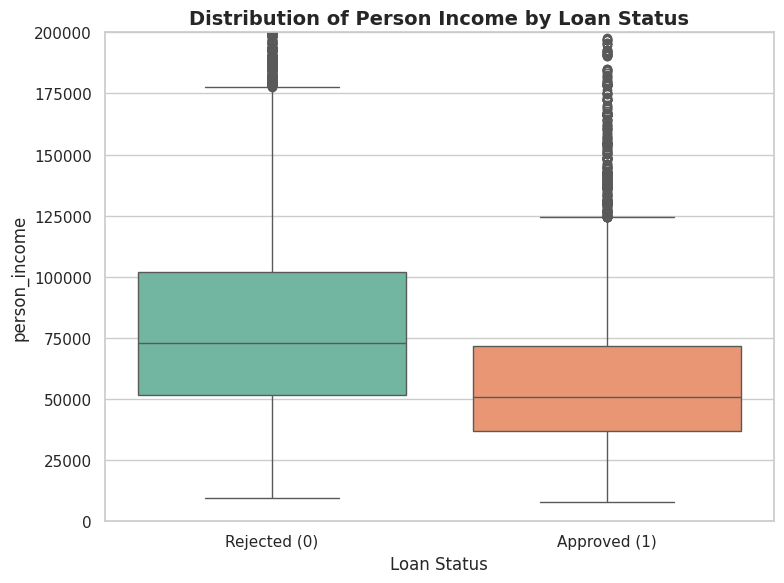

/tmp/ipykernel_26362/2360296455.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x, y=y, data=data, palette="Set2")


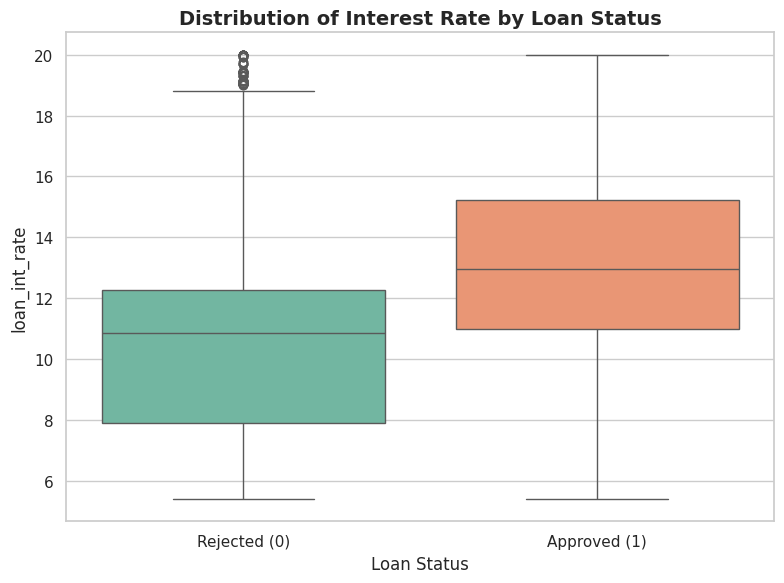

/tmp/ipykernel_26362/2360296455.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x, y=y, data=data, palette="Set2")


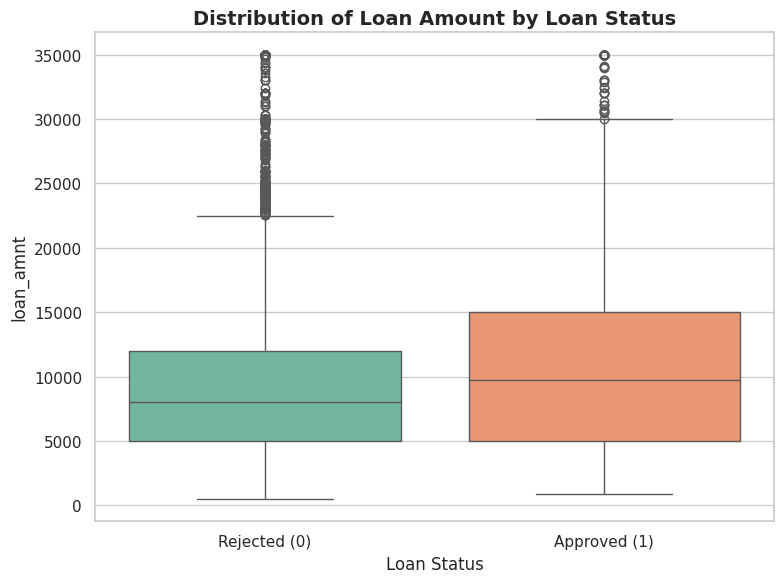

/tmp/ipykernel_26362/2360296455.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x, y=y, data=data, palette="Set2")


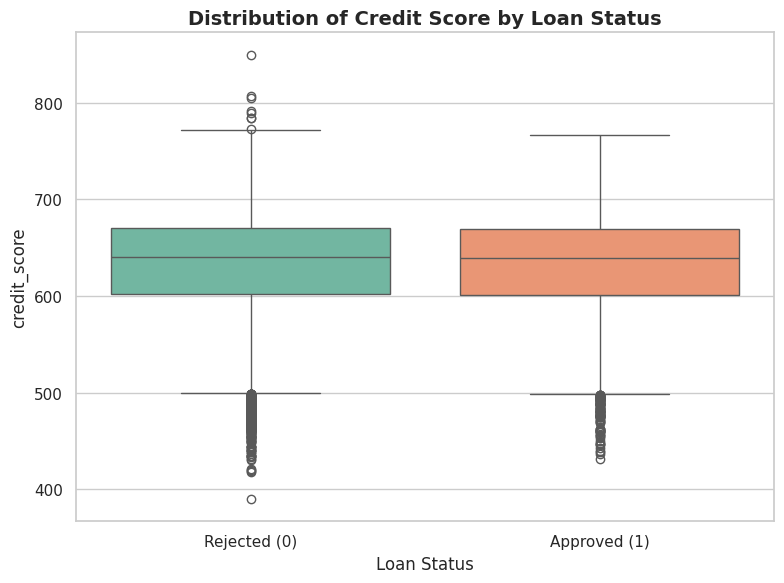

In [2]:
# Box plot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'Loan Approval Insights Data to Decision-Making.csv'
df = pd.read_csv(file_path)

sns.set(style="whitegrid")

def save_boxplot(x, y, data, title, ylabel, filename, ylim=None):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=x, y=y, data=data, palette="Set2")

    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel(ylabel, fontsize=12)
    plt.xlabel('Loan Status', fontsize=12)

    plt.xticks(ticks=[0, 1], labels=['Rejected (0)', 'Approved (1)'])

    if ylim:
        plt.ylim(ylim)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# Person Income Distribution Chart
save_boxplot(x='loan_status', y='person_income', data=df,
             title='Distribution of Person Income by Loan Status',
             ylabel='person_income',
             filename='boxplot_person_income_vs_status.png',
             ylim=(0, 200000))

# Interest Rate Distribution Chart
save_boxplot(x='loan_status', y='loan_int_rate', data=df,
             title='Distribution of Interest Rate by Loan Status',
             ylabel='loan_int_rate',
             filename='boxplot_int_rate_vs_status.png')

# Loan Amount Distribution Chart
save_boxplot(x='loan_status', y='loan_amnt', data=df,
             title='Distribution of Loan Amount by Loan Status',
             ylabel='loan_amnt',
             filename='boxplot_loan_amnt_vs_status.png')

# Credit Score Distribution Chart
save_boxplot(x='loan_status', y='credit_score', data=df,
             title='Distribution of Credit Score by Loan Status',
             ylabel='credit_score',
             filename='boxplot_credit_score_vs_status.png')

In [ ]:
import pandas as pd
from scipy.stats import spearmanr
import numpy as np

file_path = 'Loan Approval Insights Data to Decision-Making.csv'
df = pd.read_csv(file_path)

# Choose numerical variables
numerical_cols = df.select_dtypes(include=['number']).columns

# Initialize DataFrame
corr_df = pd.DataFrame(index=numerical_cols, columns=numerical_cols)
p_val_df = pd.DataFrame(index=numerical_cols, columns=numerical_cols)

# Calculate the Spearman correlation coefficient and p-value.
for col1 in numerical_cols:
    for col2 in numerical_cols:
        corr, p_val = spearmanr(df[col1], df[col2])
        corr_df.loc[col1, col2] = corr
        p_val_df.loc[col1, col2] = p_val # Store the values ​​first for easier subsequent processing.

# Define formatting functions that conform to academic standards.
def format_p_value(val):
    if val < 0.001:
        return "< 0.001"  # Highly significant, uniform marker
    else:
        return f"{val:.3f}" # Retain 3 decimal places.

# format
# Use applymap to apply a function to each element in the table.
p_val_formatted = p_val_df.applymap(format_p_value)
corr_formatted = corr_df.astype(float).round(3) # Correlation coefficients are rounded to three decimal places.


print("=== Table 1: Spearman Correlation Coefficients  ===")
print(corr_formatted)

print("\n=== Table 2: Statistical Significance (P-values)  ===")
print(p_val_formatted)


=== Table 1: Spearman Correlation Coefficients  ===
                            person_age  person_income  person_emp_exp  \
person_age                       1.000          0.143           0.888   
person_income                    0.143          1.000           0.120   
person_emp_exp                   0.888          0.120           1.000   
loan_amnt                        0.064          0.405           0.052   
loan_int_rate                    0.013         -0.033           0.016   
loan_percent_income             -0.056         -0.353          -0.050   
cb_person_cred_hist_length       0.821          0.093           0.750   
credit_score                     0.160          0.023           0.172   
loan_status                     -0.030         -0.275          -0.027   

                            loan_amnt  loan_int_rate  loan_percent_income  \
person_age                      0.064          0.013               -0.056   
person_income                   0.405         -0.033           

/tmp/ipykernel_9853/520100987.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  p_val_formatted = p_val_df.applymap(format_p_value)
